# Final Analysis Adult Census

## ???? ?????

?????????? ?????????? ???? ????????????? ? ?????????????? ???????? ?????? ? ??????? preprocessing ?? ???????? ???????.

## ?????? ????????? ? ????????? ?????

????????? CSV-????? ?? `results/`, ??????? ???? ????????? ? ?????????? ?????????.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult-census.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RANDOM_STATE = 42

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiment_utils import save_results, save_figure

sns.set_theme(style="whitegrid", context="notebook")

## ???????? ??????

- ????????????? ????????????? ?????? ?? ???????? ???????: ?????? ???????? ???? F1-score ???? baseline.
- ??????????????? ???? ????????? ?????? ??? Logistic Regression: F1-score ????? ? 0.6539 ?? 0.6568.
- ????? ??????? ????????? ????? KNNImputer ?? ???? ???????? ???????????? SimpleImputer ?? ???? ????????.
- ???????????? ??????? ????????? ???????? ???????? ??? F1-score: SMOTE ??? ?????? F1-score 0.6762, ?? ?????? Accuracy.
- ?????? ?????? ??-??????? ????????? ?? preprocessing: ????? ??????? ?????? F1-score ??? RandomForestClassifier, ? ?????? ROC-AUC ? LogisticRegression.
- Accuracy ?????? ???????????? ??? ???????????? ??????? ??? ?????????? ???????, ?????? ??? ????????? minority class ????? ?????????????? ????????? ????? ???? ?????????? ???????.
- `Pipeline` ? `ColumnTransformer` ????????? ???????? data leakage, ?????? ??? ??? ????????? preprocessing ????????? ?????? ?? train-?????. SMOTE ???????????? ?????? ?????? `imblearn.pipeline.Pipeline` ????? preprocessing.

In [2]:
baseline_results = pd.read_csv(RESULTS_DIR / "baseline_results.csv")
scaling_results = pd.read_csv(RESULTS_DIR / "scaling_results.csv")
imputation_results = pd.read_csv(RESULTS_DIR / "imputation_results.csv")
balancing_results = pd.read_csv(RESULTS_DIR / "balancing_results.csv")
models_results = pd.read_csv(RESULTS_DIR / "models_comparison_results.csv")

[len(df) for df in [baseline_results, scaling_results, imputation_results, balancing_results, models_results]]

[1, 3, 2, 3, 4]

## ??????????? ??????

??? ????????? ??????? ????????? ?????? ??????? `Variant`, ??????? ????????? ?????????? ??????? ????????????.

In [3]:
baseline_summary = baseline_results.copy()
baseline_summary["Variant"] = baseline_summary["Experiment"]

scaling_summary = scaling_results.copy()
scaling_summary["Variant"] = scaling_summary["Preprocessing"]

imputation_summary = imputation_results.copy()
imputation_summary["Variant"] = imputation_summary["Preprocessing"]

balancing_summary = balancing_results.copy()
balancing_summary["Variant"] = balancing_summary["Balancing"]

models_summary = models_results.copy()
models_summary["Variant"] = models_summary["Model"]

common_columns = ["Dataset", "Experiment", "Model", "Variant", "Accuracy", "F1-score", "ROC-AUC"]
final_summary_results = pd.concat([
    baseline_summary[common_columns],
    scaling_summary[common_columns],
    imputation_summary[common_columns],
    balancing_summary[common_columns],
    models_summary[common_columns],
], ignore_index=True)

final_summary_results = final_summary_results.round(4)
save_results(final_summary_results, RESULTS_DIR / "final_summary_results.csv")
final_summary_results

,Dataset,Experiment,Model,Variant,Accuracy,F1-score,ROC-AUC
0,Adult,Baseline,LogisticRegression,Baseline,0.8520,0.6539,0.9012
1,Adult,Scaling,LogisticRegression,No scaling,0.8520,0.6539,0.9012
2,Adult,Scaling,LogisticRegression,StandardScaler,0.8525,0.6568,0.9040
3,Adult,Scaling,LogisticRegression,MinMaxScaler,0.8525,0.6547,0.9021
4,Adult,Imputation,LogisticRegression,SimpleImputer median/mode,0.8525,0.6568,0.9040
5,Adult,Imputation,LogisticRegression,KNNImputer numeric,0.8525,0.6568,0.9040
6,Adult,Balancing,LogisticRegression,No balancing,0.8525,0.6568,0.9040
7,Adult,Balancing,LogisticRegression,class_weight balanced,0.8060,0.6747,0.9042
8,Adult,Balancing,LogisticRegression,SMOTE,0.8071,0.6762,0.9034
9,Adult,Models comparison,LogisticRegression,LogisticRegression,0.8525,0.6568,0.9040


## ?????? ?????????? ?? ????????

?????????, ????? ???????? ???? ?????? F1-score ? ROC-AUC.

In [4]:
best_f1 = final_summary_results.sort_values("F1-score", ascending=False).head(5)
best_roc_auc = final_summary_results.sort_values("ROC-AUC", ascending=False).head(5)

best_f1, best_roc_auc

(   Dataset         Experiment                   Model                 Variant  \
 8    Adult          Balancing      LogisticRegression                   SMOTE   
 7    Adult          Balancing      LogisticRegression   class_weight balanced   
 11   Adult  Models comparison  RandomForestClassifier  RandomForestClassifier   
 12   Adult  Models comparison           MLPClassifier           MLPClassifier   
 2    Adult            Scaling      LogisticRegression          StandardScaler   
 
     Accuracy  F1-score  ROC-AUC  
 8     0.8071    0.6762   0.9034  
 7     0.8060    0.6747   0.9042  
 11    0.8505    0.6631   0.8932  
 12    0.8517    0.6625   0.9004  
 2     0.8525    0.6568   0.9040  ,
   Dataset  Experiment               Model                    Variant  \
 7   Adult   Balancing  LogisticRegression      class_weight balanced   
 4   Adult  Imputation  LogisticRegression  SimpleImputer median/mode   
 6   Adult   Balancing  LogisticRegression               No balancing   
 5 

## ???????? ??????

- ????????????? ????????????? ?????? ?? ???????? ???????: ?????? ???????? ???? F1-score ???? baseline.
- ??????????????? ???? ????????? ?????? ??? Logistic Regression: F1-score ????? ? 0.6539 ?? 0.6568.
- ????? ??????? ????????? ????? KNNImputer ?? ???? ???????? ???????????? SimpleImputer ?? ???? ????????.
- ???????????? ??????? ????????? ???????? ???????? ??? F1-score: SMOTE ??? ?????? F1-score 0.6762, ?? ?????? Accuracy.
- ?????? ?????? ??-??????? ????????? ?? preprocessing: ????? ??????? ?????? F1-score ??? RandomForestClassifier, ? ?????? ROC-AUC ? LogisticRegression.
- Accuracy ?????? ???????????? ??? ???????????? ??????? ??? ?????????? ???????, ?????? ??? ????????? minority class ????? ?????????????? ????????? ????? ???? ?????????? ???????.
- `Pipeline` ? `ColumnTransformer` ????????? ???????? data leakage, ?????? ??? ??? ????????? preprocessing ????????? ?????? ?? train-?????. SMOTE ???????????? ?????? ?????? `imblearn.pipeline.Pipeline` ????? preprocessing.

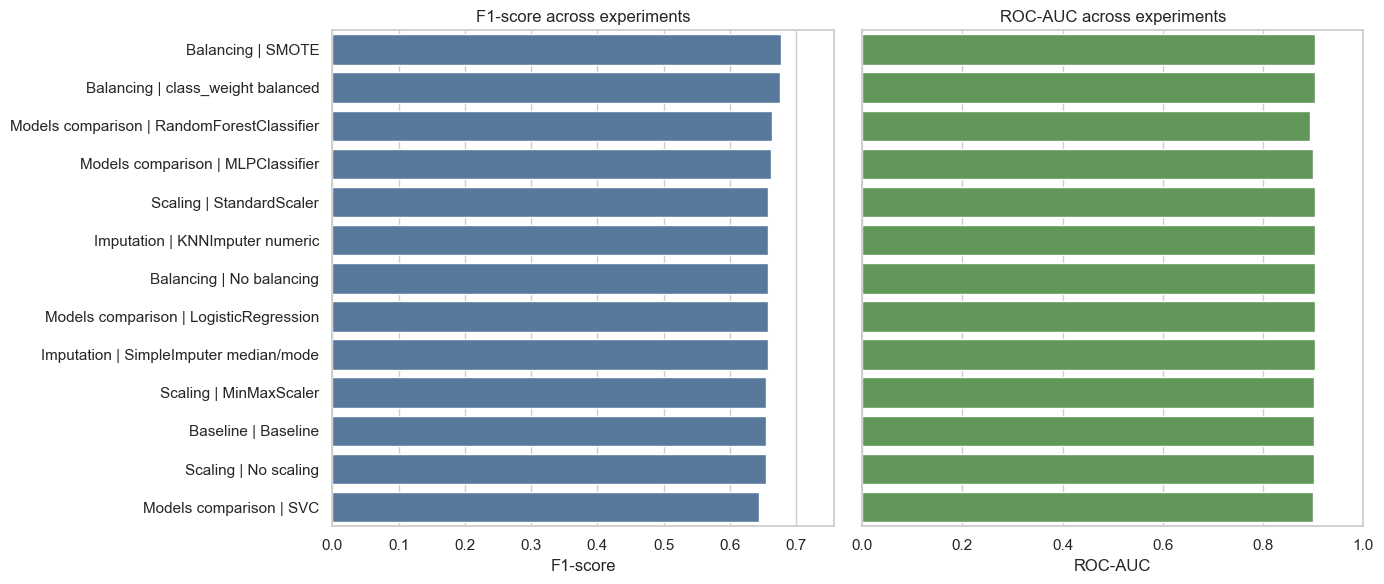

In [5]:
plot_df = final_summary_results.copy()
plot_df["Label"] = plot_df["Experiment"] + " | " + plot_df["Variant"]
plot_df = plot_df.sort_values("F1-score", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(data=plot_df, y="Label", x="F1-score", ax=axes[0], color="#4c78a8")
axes[0].set_title("F1-score across experiments")
axes[0].set_xlabel("F1-score")
axes[0].set_ylabel("")
axes[0].set_xlim(0, max(plot_df["F1-score"]) + 0.08)

sns.barplot(data=plot_df, y="Label", x="ROC-AUC", ax=axes[1], color="#59a14f")
axes[1].set_title("ROC-AUC across experiments")
axes[1].set_xlabel("ROC-AUC")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()
save_figure(FIGURES_DIR / "final_summary_metrics.png")
plt.show()

## ???????? ??????

- ????????????? ????????????? ?????? ?? ???????? ???????: ?????? ???????? ???? F1-score ???? baseline.
- ??????????????? ???? ????????? ?????? ??? Logistic Regression: F1-score ????? ? 0.6539 ?? 0.6568.
- ????? ??????? ????????? ????? KNNImputer ?? ???? ???????? ???????????? SimpleImputer ?? ???? ????????.
- ???????????? ??????? ????????? ???????? ???????? ??? F1-score: SMOTE ??? ?????? F1-score 0.6762, ?? ?????? Accuracy.
- ?????? ?????? ??-??????? ????????? ?? preprocessing: ????? ??????? ?????? F1-score ??? RandomForestClassifier, ? ?????? ROC-AUC ? LogisticRegression.
- Accuracy ?????? ???????????? ??? ???????????? ??????? ??? ?????????? ???????, ?????? ??? ????????? minority class ????? ?????????????? ????????? ????? ???? ?????????? ???????.
- `Pipeline` ? `ColumnTransformer` ????????? ???????? data leakage, ?????? ??? ??? ????????? preprocessing ????????? ?????? ?? train-?????. SMOTE ???????????? ?????? ?????? `imblearn.pipeline.Pipeline` ????? preprocessing.